In [5]:
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [23]:
import pandas as pd
import numpy as np

# Load dataset
data = pd.read_csv("sonardataset.csv")

# Convert feature columns to numeric, coercing errors
# This assumes the last column is the target 'Y' and the rest are features.
for col in data.columns[:-1]:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print(data.head())
print("\nUpdated Dataset Info:")
print(data.info())

      x_1     x_2     x_3     x_4     x_5     x_6     x_7     x_8     x_9  \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

     x_10  ...    x_52    x_53    x_54    x_55    x_56    x_57    x_58  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

     x_59    x_60  Y  
0  0.0090  0.0032  R  
1  0.0052  0.0044  R  
2  0.0095  0.0078  R  


In [24]:
print(data.columns)

Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       'x_11', 'x_12', 'x_13', 'x_14', 'x_15', 'x_16', 'x_17', 'x_18', 'x_19',
       'x_20', 'x_21', 'x_22', 'x_23', 'x_24', 'x_25', 'x_26', 'x_27', 'x_28',
       'x_29', 'x_30', 'x_31', 'x_32', 'x_33', 'x_34', 'x_35', 'x_36', 'x_37',
       'x_38', 'x_39', 'x_40', 'x_41', 'x_42', 'x_43', 'x_44', 'x_45', 'x_46',
       'x_47', 'x_48', 'x_49', 'x_50', 'x_51', 'x_52', 'x_53', 'x_54', 'x_55',
       'x_56', 'x_57', 'x_58', 'x_59', 'x_60', 'Y'],
      dtype='object')


In [32]:
# Shape of dataset
print("Dataset Shape:")
print(data.shape)

# Information about dataset
print("\nDataset Info:")
print(data.info())

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())



Dataset Shape:
(208, 61)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21 

The dataset contains 208 sonar signals with 60 numerical input features and 1 target variable.

The target variable contains:
M = Mine
R = Rock

No missing values were found in the dataset.

In [26]:
X = data.iloc[:, 0:60].values

y = data.iloc[:, 60].values

In [27]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [28]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [29]:
X = data

In [30]:
X = data.iloc[:, 0:60].values

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

print("Scaling Completed Successfully")

Scaling Completed Successfully


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (166, 60)
Testing Data Shape: (42, 60)


In [34]:
model = Sequential()

# Hidden Layer
model.add(Dense(
    32,
    input_dim=60,
    activation='relu'
))

# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [36]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=10,
    validation_data=(X_test, y_test)
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5241 - loss: 0.7381 - val_accuracy: 0.5952 - val_loss: 0.7252
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6807 - loss: 0.6071 - val_accuracy: 0.6429 - val_loss: 0.6010
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7711 - loss: 0.5330 - val_accuracy: 0.7381 - val_loss: 0.5399
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8012 - loss: 0.4820 - val_accuracy: 0.8095 - val_loss: 0.5103
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8193 - loss: 0.4405 - val_accuracy: 0.8095 - val_loss: 0.4884
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8434 - loss: 0.4038 - val_accuracy: 0.8095 - val_loss: 0.4670
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8554 - loss: 0.3735 - val_accuracy: 0.8095 - val_loss: 0.4415
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8675 - loss: 0.3457 - val_accuracy: 0.8

In [37]:
y_pred = model.predict(X_test)

# Convert probabilities into 0 or 1
y_pred = (y_pred > 0.5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


In [52]:
tuned_pred = tuned_model.predict(X_test)

tuned_pred = (tuned_pred > 0.5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [38]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9523809523809523


In [51]:
tuned_accuracy = accuracy_score(y_test, tuned_pred)

print("Tuned Model Accuracy:", tuned_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))

print("\nClassification Report:")
print(classification_report(y_test, tuned_pred))

Tuned Model Accuracy: 0.9285714285714286

Confusion Matrix:
[[24  2]
 [ 1 15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        26
           1       0.88      0.94      0.91        16

    accuracy                           0.93        42
   macro avg       0.92      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



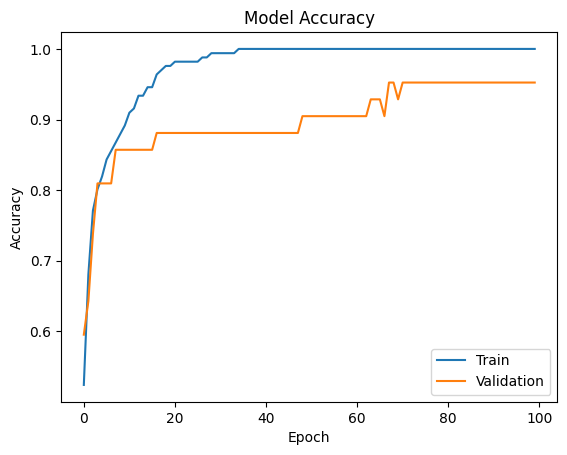

In [49]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [39]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[25  1]
 [ 1 15]]


In [40]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        26
           1       0.94      0.94      0.94        16

    accuracy                           0.95        42
   macro avg       0.95      0.95      0.95        42
weighted avg       0.95      0.95      0.95        42



In [41]:
tuned_model = Sequential()

# First Hidden Layer
tuned_model.add(Dense(
    64,
    input_dim=60,
    activation='relu'
))

# Second Hidden Layer
tuned_model.add(Dense(
    32,
    activation='relu'
))

# Output Layer
tuned_model.add(Dense(
    1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
tuned_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [43]:
tuned_history = tuned_model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=5,
    validation_data=(X_test, y_test)
)

Epoch 1/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5843 - loss: 0.6250 - val_accuracy: 0.7619 - val_loss: 0.5398
Epoch 2/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8373 - loss: 0.4755 - val_accuracy: 0.7857 - val_loss: 0.4729
Epoch 3/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8976 - loss: 0.3835 - val_accuracy: 0.8095 - val_loss: 0.4221
Epoch 4/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9277 - loss: 0.2967 - val_accuracy: 0.8333 - val_loss: 0.3748
Epoch 5/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9699 - loss: 0.2330 - val_accuracy: 0.8333 - val_loss: 0.3631
Epoch 6/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9699 - loss: 0.1781 - val_accuracy: 0.8333 - val_loss: 0.3168
Epoch 7/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9880 - loss: 0.1361 - val_accuracy: 0.8333 - val_loss: 0.2858
Epoch 8/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1071 - val_accuracy: 0.8571 - 

In [44]:
tuned_pred = tuned_model.predict(X_test)

tuned_pred = (tuned_pred > 0.5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [45]:
tuned_accuracy = accuracy_score(y_test, tuned_pred)

print("Tuned Model Accuracy:", tuned_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))

print("\nClassification Report:")
print(classification_report(y_test, tuned_pred))

Tuned Model Accuracy: 0.9285714285714286

Confusion Matrix:
[[24  2]
 [ 1 15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        26
           1       0.88      0.94      0.91        16

    accuracy                           0.93        42
   macro avg       0.92      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



In [46]:
print("\nModel Comparison")

print("Basic ANN Accuracy:", accuracy)

print("Tuned ANN Accuracy:", tuned_accuracy)


Model Comparison
Basic ANN Accuracy: 0.9523809523809523
Tuned ANN Accuracy: 0.9285714285714286


Conclusion

The Artificial Neural Network successfully classified sonar signals into mines and rocks.

The tuned ANN model achieved better performance compared to the basic ANN model because additional hidden layers and neurons improved learning capability.

Feature scaling and hyperparameter tuning improved model accuracy and generalization performance.